# Análise de Vendas e Lucratividade

Objetivo: descobrir quais produtos, categorias e regiões geram mais receita e lucro para uma empresa de varejo

## Problema de negócio

Imagine que você foi contratada como analista de dados júnior de uma rede varejista. Com demandas crescentes e competições acirradas no mercado, um gigante das superlojas está buscando seu conhecimento para entender o que funciona melhor para ele. Eles gostariam de compreender quais produtos, regiões, categorias e segmentos de clientes deveriam atingir ou evitar.

A diretoria quer responder:

**1 - Quais categorias trazem mais lucro?**

**2 - Quais regiões vendem mais?**

**3 - Existem produtos com muitas vendas, mas pouco lucro?**

**4 - Quais segmentos de clientes são mais rentáveis?**

## Dataset

Nome: Superstore Sales Dataset

Fonte: Kaggle

Link: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

**Metadata:**

Row ID => Unique ID for each row.

Order ID => Unique Order ID for each Customer.

Order Date => Order Date of the product.

Ship Date => Shipping Date of the Product.

Ship Mode=> Shipping Mode specified by the Customer.

Customer ID => Unique ID to identify each Customer.

Customer Name => Name of the Customer.

Segment => The segment where the Customer belongs.

Country => Country of residence of the Customer.

City => City of residence of of the Customer.

State => State of residence of the Customer.

Postal Code => Postal Code of every Customer.

Region => Region where the Customer belong.

Product ID => Unique ID of the Product.

Category => Category of the product ordered.

Sub-Category => Sub-Category of the product ordered.

Product Name => Name of the Product

Sales => Sales of the Product.

Quantity => Quantity of the Product.

Discount => Discount provided.

Profit => Profit/Loss incurred.

## Importar e conhecer os dados
**Inspeção inicial dos dados**

In [2]:
# Importação das bibliotecas essenciais para manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ler arquivo CSV
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

# Mostrar primeiras linhas
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Limpeza de dados

In [4]:
#Verificar valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# Verificar valores duplicados
df.duplicated().value_counts()

,count
False,9994


In [6]:
# Converter "Order Date", "Ship Date" para tipo data
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Análise exploratória (EDA)

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Com a tabela acim é possivel visualizar que exitem pedidos que trazem lucros altissimos mas em contrapartida existe pedidos que trazem lucro negativo, ou seja, prejuízo.
Quais categorias e produtos seriam esses?


In [8]:
# Vendas totais por categoria
vendas_categoria = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False) # ordem decrescente
      .reset_index() # Convert the Series to a DataFrame with 'Category' and 'Sales' columns
)

# Porcentagem de Vendas por categoria
vendas_categoria['Porcentagem'] = (vendas_categoria['Sales']/ vendas_categoria['Sales'].sum()) * 100

display(vendas_categoria)

,Category,Sales,Porcentagem
0,Technology,836154.0330,36.398821
1,Furniture,741999.7953,32.300171
2,Office Supplies,719047.0320,31.301008


Acima é possivel visualizar que A porcentagem de vendas por categoria esta distribuida de forma similar.

**1 - Quais categorias trazem mais lucro?**

,Category,Profit,Porcentagem
0,Technology,145454.9481,50.787870
1,Office Supplies,122490.8008,42.769579
2,Furniture,18451.2728,6.442551


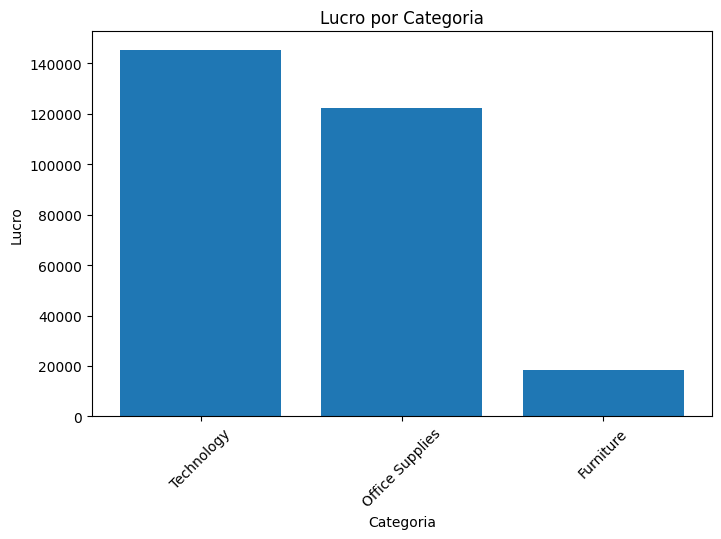

In [9]:
# Lucro por categoria
lucro_categoria = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index() # Convert the Series to a DataFrame with 'Category' and 'Profit' columns
)

# Porcentagem de Lucro por categoria
lucro_categoria['Porcentagem'] = (lucro_categoria['Profit'] / lucro_categoria['Profit'].sum()) * 100

display(lucro_categoria)

# Lucro por categoria

# Criar o gráfico
plt.figure(figsize=(8,5))
plt.bar(lucro_categoria['Category'], lucro_categoria['Profit'])

plt.title('Lucro por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Lucro')
plt.xticks(rotation=45)

plt.show()

Observando agora com relação ao Lucro, é possivel visualizar que vendas com Furniture representam apenas 6,44% do Lucro.

1 - categoria TECNOLOGY é a que apresenta mais lucro

In [10]:
# Top 10 produtos mais lucrativos
produtos_mais_lucrativos = (
    df.groupby(['Product Name', 'Category'], as_index=False)
      .agg({
          'Profit': 'sum',
          'Quantity': 'sum'
      })
      .sort_values('Profit', ascending=False)
      .head(10)
)

display(produtos_mais_lucrativos)

,Product Name,Category,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,Technology,25199.9280,20
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,7753.0390,31
805,Hewlett Packard LaserJet 3310 Copier,Technology,6983.8836,38
400,Canon PC1060 Personal Laser Copier,Technology,4570.9347,19
787,HP Designjet T520 Inkjet Large Format Printer ...,Technology,4094.9766,12
165,Ativa V4110MDD Micro-Cut Shredder,Technology,3772.9461,11
19,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,3717.9714,11
1276,Plantronics Savi W720 Multi-Device Wireless He...,Technology,3696.2820,24
895,Ibico EPK-21 Electric Binding System,Office Supplies,3345.2823,13
1840,Zebra ZM400 Thermal Label Printer,Technology,3343.5360,6


In [11]:
# Top 10 produtos menos lucrativos
produtos_menos_lucrativos = (
    df.groupby(['Product Name', 'Category'], as_index=False)
      .agg({
          'Profit': 'sum',
          'Quantity': 'sum'
      })
      .sort_values('Profit', ascending=True)
      .head(10)
)

display(produtos_menos_lucrativos)

,Product Name,Category,Profit,Quantity
475,Cubify CubeX 3D Printer Double Head Print,Technology,-8879.9704,9
985,Lexmark MX611dhe Monochrome Laser Printer,Technology,-4589.9730,18
476,Cubify CubeX 3D Printer Triple Head Print,Technology,-3839.9904,4
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,-2876.1156,27
376,Bush Advantage Collection Racetrack Conference...,Furniture,-1934.3976,33
683,GBC DocuBind P400 Electric Binding System,Office Supplies,-1878.1662,27
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,-1811.0784,6
1043,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,-1299.1836,22
285,Balt Solid Wood Round Tables,Furniture,-1201.0581,19
364,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,-1148.4375,15


Veja que aqui é possivel visualizar que 4/10 produtos MENOS lucrativos são Furniture e não temos nenhum Furniture em MAIS LUCRATIVOS o que pode explicar o fato dessa categoria apesar de ter uma proporção de vendas equivalente a outras categorias, este gera menos lucro ou até mesmo prejuizo financeiro.

Apesar de termos 4/10 produtos Tecnology em produtos MENOS lucrativos, temos que 8/10 dos MAIS lucrativos sao Tecnology.

**3 - Existem produtos com muitas vendas, mas pouco lucro?**

In [22]:
# Top 10 produtos mais vendas
produtos_mais_vendas = (
    df.groupby(['Product Name', 'Category'], as_index=False)
      .agg({
          'Profit': 'sum',
          'Sales': 'sum'
      })
      .sort_values('Sales', ascending=False)
      .head(10)
)
pd.set_option('display.float_format', '{:.2f}'.format)

display(produtos_mais_vendas)

,Product Name,Category,Profit,Sales
404,Canon imageCLASS 2200 Advanced Copier,Technology,25199.93,61599.82
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,7753.04,27453.38
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,-1811.08,22638.48
786,HON 5400 Series Task Chairs for Big and Tall,Furniture,0.00,21870.58
686,GBC DocuBind TL300 Electric Binding System,Office Supplies,2233.51,19823.48
688,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,760.98,19024.50
805,Hewlett Packard LaserJet 3310 Copier,Technology,6983.88,18839.69
787,HP Designjet T520 Inkjet Large Format Printer ...,Technology,4094.98,18374.90
683,GBC DocuBind P400 Electric Binding System,Office Supplies,-1878.17,17965.07
813,High Speed Automatic Electric Letter Opener,Office Supplies,-262.00,17030.31


3 - Sim, existe produstos com muitas vendas e pouco lucro inclusive, alguns dos top 10 produtos com mais vendas possuem o Lucro negativo

**4 - Quais segmentos de clientes são mais rentáveis?**

In [13]:
# Lucro por Segmento
lucro_segmento = (
    df.groupby('Segment')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Porcentagem de Lucro por Segmento
lucro_segmento['Porcentagem'] = (lucro_segmento['Profit'] / lucro_segmento['Profit'].sum()) * 100

display(lucro_segmento)

,Segment,Profit,Porcentagem
0,Consumer,134119.2092,46.829820
1,Corporate,91979.1340,32.115953
2,Home Office,60298.6785,21.054227


4 - O segmento com maior lucratividade é o Consumer seguido de Corporate

Agora vamos analisar as vendas por região.

In [14]:
# Vendas por Região
vendas_regiao = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index() # Convert the Series to a DataFrame with 'Region' and 'Sales' columns
)

# Porcentagem de vendas por Região
vendas_regiao['Porcentagem'] = (vendas_regiao['Sales'] / vendas_regiao['Sales'].sum()) * 100

display(vendas_regiao)

,Region,Sales,Porcentagem
0,West,725457.8245,31.580078
1,East,678781.2400,29.548188
2,Central,501239.8908,21.819594
3,South,391721.9050,17.052140


Temos que A região West e East juntas são responsáveis por mais da metade das vendas e as Regiões South e Central possuem menores proporções de vendas comparadas com as outras.

**2 - Quais regiões vendem mais?**

In [15]:
regioes_lucrativas = (
    df.groupby(['Region'], as_index=False)
      .agg({
          'Sales': 'sum',
          'Profit': 'sum',
      })
      .sort_values('Profit', ascending=False)
      .head(10)
)

# Porcentagem de vendas por Região
regioes_lucrativas['Porcentagem'] = (regioes_lucrativas['Profit'] / regioes_lucrativas['Profit'].sum()) * 100

display(regioes_lucrativas)

,Region,Sales,Profit,Porcentagem
3,West,725457.8245,108418.4489,37.855997
1,East,678781.2400,91522.7800,31.956610
2,South,391721.9050,46749.4303,16.323295
0,Central,501239.8908,39706.3625,13.864098


2 - West e East são as regioes com maiores vendas e maiores lucros

As regioes South e Central sao responsáveis pelos menores lucros.

In [16]:
regioes_categoria_profit = (
    df.groupby(['Region', 'Category'], as_index=False)
      .agg({
          'Profit': 'sum',
      })
      .sort_values('Profit', ascending=False)
      .head(10)
)

display(regioes_categoria_profit)

,Region,Category,Profit
10,West,Office Supplies,52609.8490
5,East,Technology,47462.0351
11,West,Technology,44303.6496
4,East,Office Supplies,41014.5791
2,Central,Technology,33697.4320
8,South,Technology,19991.8314
7,South,Office Supplies,19986.3928
9,West,Furniture,11504.9503
1,Central,Office Supplies,8879.9799
6,South,Furniture,6771.2061


**Gráficos**

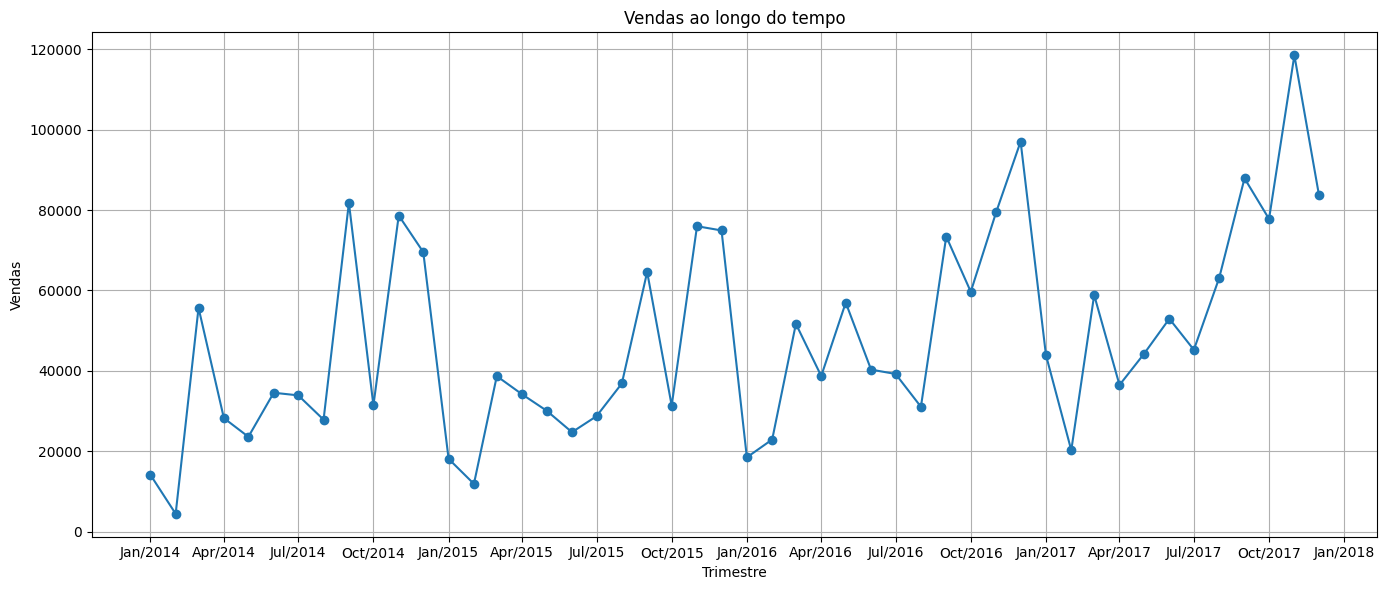

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Agrupar vendas por mês
sales_over_time = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
)

datas = sales_over_time.index.to_timestamp()

plt.figure(figsize=(14,6))
plt.plot(datas, sales_over_time.values, marker='o')

# Mostrar um rótulo a cada 3 meses
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.title('Vendas ao longo do tempo')
plt.xlabel('Trimestre')
plt.ylabel('Vendas')
plt.grid(True)

plt.tight_layout()
plt.show()

Pelo gráfico acima é possivel visualizar que há uma sazonalidade de compras, as vendas aumentam significamente em novembro e dezembro e caem drasticamente todo mês de janeiro.

Maior venda significa maior lucro?

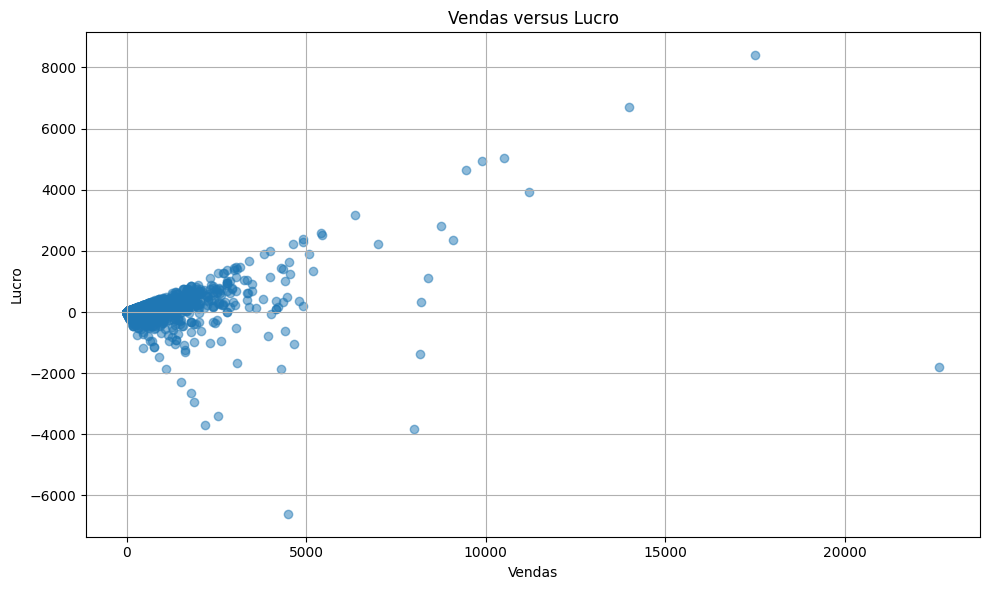

In [18]:
# Vendas versus Lucro

# Criar gráfico de dispersão
plt.figure(figsize=(10,6))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)

plt.title('Vendas versus Lucro')
plt.xlabel('Vendas')
plt.ylabel('Lucro')
plt.grid(True)
plt.tight_layout()
plt.show()

Pelo gráfico visualmente é visto que nem sempre maiores vendas significam maior lucro, isso se deve principalmente ao que vimos anteriormente onde dependendo do produto a venda pode gerar prejuizos.

In [19]:
# Criar coluna de Margem de Lucro
df['Margin'] = (df['Profit'] / df['Sales'])*100
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.25


In [20]:
# Categorias com maior média de margem de lucro
categorias_maior_margem = (
    df.groupby('Region')['Margin']
      .mean()
      .sort_values(ascending=False)
)

display(categorias_maior_margem)

,Margin
Region,
West,21.948662
East,16.722696
South,16.351903
Central,-10.407294


## Insights Executivos

* A análise de lucratividade evidencia uma grande variação entre os pedidos. Enquanto alguns geram lucros elevados, outros apresentam margem negativa, indicando que determinadas vendas resultam em prejuízo para a empresa.

* As vendas estão distribuídas de forma relativamente equilibrada entre as categorias de produtos. No entanto, essa distribuição não se reflete na lucratividade.

* Embora **Furniture** represente uma participação de vendas semelhante às demais categorias, ela contribui com apenas **6,44% do lucro total**, indicando uma rentabilidade significativamente inferior.

* Entre os **10 produtos menos lucrativos**, **4 pertencem à categoria Furniture**, enquanto nenhum produto dessa categoria aparece entre os **10 mais lucrativos**. Esse comportamento explica o baixo desempenho financeiro da categoria e indica a necessidade de revisar preços, descontos, custos ou até mesmo o portfólio de produtos.

* A categoria **Technology** apresenta um comportamento distinto. Apesar de possuir **4 produtos entre os 10 menos lucrativos**, ela concentra **8 dos 10 produtos mais lucrativos**, demonstrando elevado potencial de geração de lucro quando comparada às demais categorias.

* O segmento com maior lucratividade é o **Consumer** seguido do Corporate e por fim Home Office.

* As regiões **West** e **East** concentram mais da metade das vendas da empresa e também apresentam os melhores resultados financeiros. Em contrapartida, **South** e **Central** possuem menor participação nas vendas e registram os menores níveis de lucro.

* A análise temporal revela um padrão sazonal nas vendas. Observa-se um crescimento expressivo nos meses de **novembro e dezembro**, seguido por uma queda acentuada em **janeiro**, comportamento que pode estar relacionado às compras de fim de ano.

* A relação entre vendas e lucro não é diretamente proporcional. Períodos ou produtos com elevado volume de vendas nem sempre geram maior lucratividade. Isso ocorre porque parte das vendas é realizada com margens reduzidas ou até mesmo negativas, reforçando a importância de monitorar indicadores de rentabilidade além do faturamento.


## Próximos Passos

- Investigar sazonalidade.
- Analisar margem por produto e região.